# Sentinel-2 Lava Lake Monitoring 🌋🛰️

> ** 🤖 AI-Generated Notebook**
> This notebook was developed collaboratively with an AI assistant through a series of iterative prompts. We kept the notebook code and comments as close as possible to the output of the AI to show you what is possible - black formatting was applied automatically as requested by the notebook-samples repository. In a real world case, the notebook would require careful review and checking, adding more .md cells and better commenting to make it easier to work with. The core steps of this workflow were generated based on the following key user requests:
> 
> * **Architecture Validation:** Inquired about using the CDSE Sentinel Hub Statistics API and SWIR bands to automate lava lake monitoring without downloading massive data volumes.
> * **Visual Evalscript:** Requested a custom Evalscript to dynamically render hot pixels as a SWIR composite and cold pixels in true color.
> * **Statistical Evalscript:** Refined the Evalscript to output both visual bands and raw statistical indices (Normalized Hotspot Index and B12 radiance) simultaneously.
> * **Area of Interest Generation:** Asked for the generation of bounding box coordinates for 10 of the most active lava lakes on Earth.
> * **API Integration:** Requested Jupyter Python code to authenticate with CDSE endpoints and fetch recent optical/thermal imagery while handling cloud cover thresholds.
> * **Time-Series Data Extraction:** Requested a Statistical API query to extract the maximum heat indices over 14-day intervals for the past year into Pandas DataFrames.
> * **Data Visualization:** Asked for dual-axis line charts to plot the one-year historical thermal activity of each volcano.
> * **Interactive Dashboard & Live Query:** Requested an interactive time-slider using `ipywidgets` to classify historical activity, and a final dynamic query to print a list of *currently* active lava lakes.

---

This notebook demonstrates an automated workflow for monitoring thermal anomalies at 10 of the most active lava lakes on Earth using the **Copernicus Data Space Ecosystem (CDSE)**. 

We will use the Sentinel Hub Python API to:
1. Authenticate with our CDSE OAuth client credentials.
2. Query the latest Sentinel-2 L2A (atmospherically corrected) optical imagery for our target bounding boxes.
3. Apply a relaxed 80% maximum cloud cover threshold to ensure we capture active vents even in stormy regions.
4. Query the Statistical API to generate dataframes of maximum SWIR radiance and Normalized Hotspot Indices (SHI).
5. Visualize the historical timelines and current active status of these volcanoes.

In [2]:
# %% [code]
import getpass
from sentinelhub import SHConfig

print("Please enter your CDSE OAuth Client credentials.")
client_id = getpass.getpass("Client ID: ")
client_secret = getpass.getpass("Client Secret: ")

# Configure Sentinel Hub specifically for the CDSE endpoint
config = SHConfig()
config.sh_client_id = client_id
config.sh_client_secret = client_secret
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

print("Authentication configuration complete.")

Please enter your CDSE OAuth Client credentials.


Client ID:  ········
Client Secret:  ········


Authentication configuration complete.


Fetching latest clear imagery from CDSE... This may take a moment.


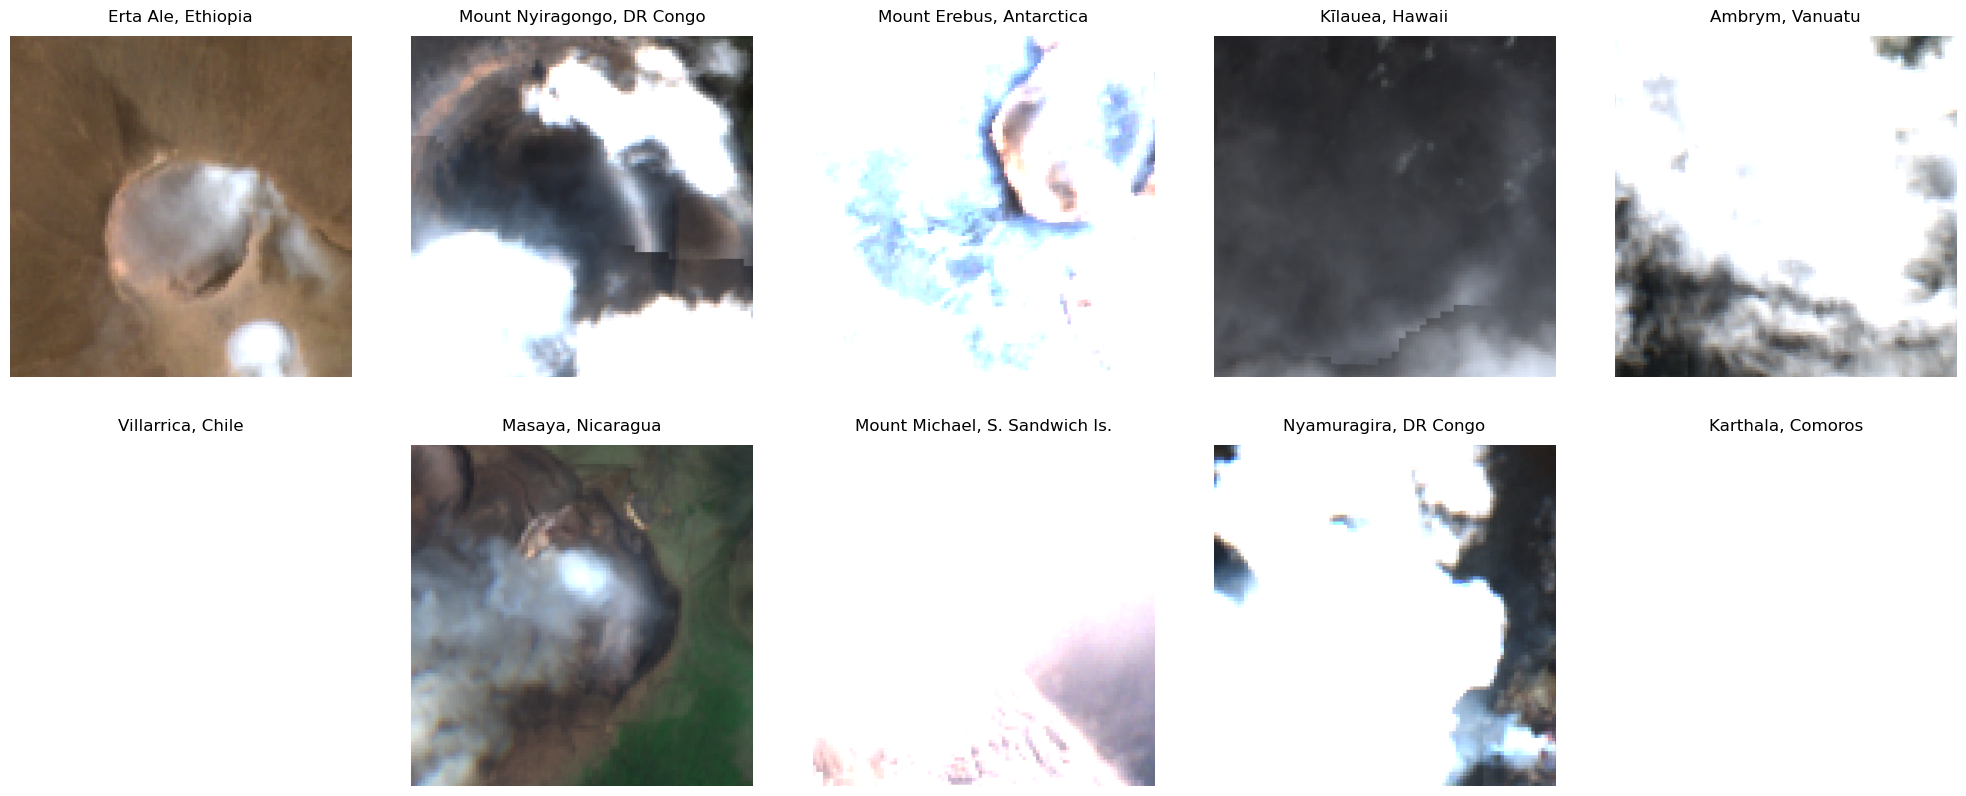

In [3]:
# %% [code]
import matplotlib.pyplot as plt
from sentinelhub import SentinelHubRequest, DataCollection, MimeType, BBox, CRS
from datetime import datetime, timedelta

# 1. Target Locations
volcanoes = [
    {
        "name": "Erta Ale, Ethiopia",
        "coords": [
            [40.6570, 13.6024],
            [40.6662, 13.6024],
            [40.6662, 13.6114],
            [40.6570, 13.6114],
        ],
    },
    {
        "name": "Mount Nyiragongo, DR Congo",
        "coords": [
            [29.2455, -1.5253],
            [29.2545, -1.5253],
            [29.2545, -1.5163],
            [29.2455, -1.5163],
        ],
    },
    {
        "name": "Mount Erebus, Antarctica",
        "coords": [
            [167.1289, -77.5342],
            [167.1705, -77.5342],
            [167.1705, -77.5252],
            [167.1289, -77.5252],
        ],
    },
    {
        "name": "Kīlauea, Hawaii",
        "coords": [
            [-155.2878, 19.4015],
            [-155.2782, 19.4015],
            [-155.2782, 19.4105],
            [-155.2878, 19.4105],
        ],
    },
    {
        "name": "Ambrym, Vanuatu",
        "coords": [
            [168.1153, -16.2545],
            [168.1247, -16.2545],
            [168.1247, -16.2455],
            [168.1153, -16.2455],
        ],
    },
    {
        "name": "Villarrica, Chile",
        "coords": [
            [-71.9358, -39.4245],
            [-71.9242, -39.4245],
            [-71.9242, -39.4155],
            [-71.9358, -39.4155],
        ],
    },
    {
        "name": "Masaya, Nicaragua",
        "coords": [
            [-86.1726, 11.9795],
            [-86.1634, 11.9795],
            [-86.1634, 11.9885],
            [-86.1726, 11.9885],
        ],
    },
    {
        "name": "Mount Michael, S. Sandwich Is.",
        "coords": [
            [-26.4585, -57.7945],
            [-26.4415, -57.7945],
            [-26.4415, -57.7855],
            [-26.4585, -57.7855],
        ],
    },
    {
        "name": "Nyamuragira, DR Congo",
        "coords": [
            [29.1955, -1.4125],
            [29.2045, -1.4125],
            [29.2045, -1.4035],
            [29.1955, -1.4035],
        ],
    },
    {
        "name": "Karthala, Comoros",
        "coords": [
            [43.3554, -11.7545],
            [43.3646, -11.7545],
            [43.3646, -11.7455],
            [43.3554, -11.7455],
        ],
    },
]

# 2. Simple True Color Evalscript
evalscript_true_color = """
//VERSION=3
function setup() {
    return {
        input: ["B02", "B03", "B04", "dataMask"],
        output: { bands: 3 }
    };
}
function evaluatePixel(sample) {
    if (sample.dataMask === 0) return [0, 0, 0];
    return [2.5 * sample.B04, 2.5 * sample.B03, 2.5 * sample.B02];
}
"""

# Force the data collection to use the CDSE endpoint from our config
cdse_s2_l2a = DataCollection.SENTINEL2_L2A.define_from(
    "S2_L2A_CDSE", service_url=config.sh_base_url
)

# 3. Setup Time Interval (Looking back 365 days)
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

# 4. Initialize Plot
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

print("Fetching latest clear imagery from CDSE... This may take a moment.")

# 5. Fetch and plot data
for i, volcano in enumerate(volcanoes):
    name = volcano["name"]
    lons = [c[0] for c in volcano["coords"]]
    lats = [c[1] for c in volcano["coords"]]

    bbox = BBox(bbox=[min(lons), min(lats), max(lons), max(lats)], crs=CRS.WGS84)

    request = SentinelHubRequest(
        evalscript=evalscript_true_color,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=cdse_s2_l2a,
                time_interval=(start_date, end_date),
                maxcc=0.80,  # 80% to allow for stormy regions
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
        bbox=bbox,
        size=(512, 512),
        config=config,
    )

    try:
        response = request.get_data()
        if response and len(response) > 0:
            axes[i].imshow(response[0])
            axes[i].set_title(name, fontsize=12, pad=10)
        else:
            axes[i].set_title(f"{name}\n(No clear data)", fontsize=12, pad=10)
            axes[i].text(
                0.5, 0.5, "No Image\n< 80% Cloud Cover", ha="center", va="center"
            )
    except Exception as e:
        axes[i].set_title(f"{name}\n(Error)", fontsize=12, pad=10)
        print(f"Error fetching {name}: {e}")

    axes[i].axis("off")

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

Fetching latest thermal imagery from CDSE... This may take a moment.


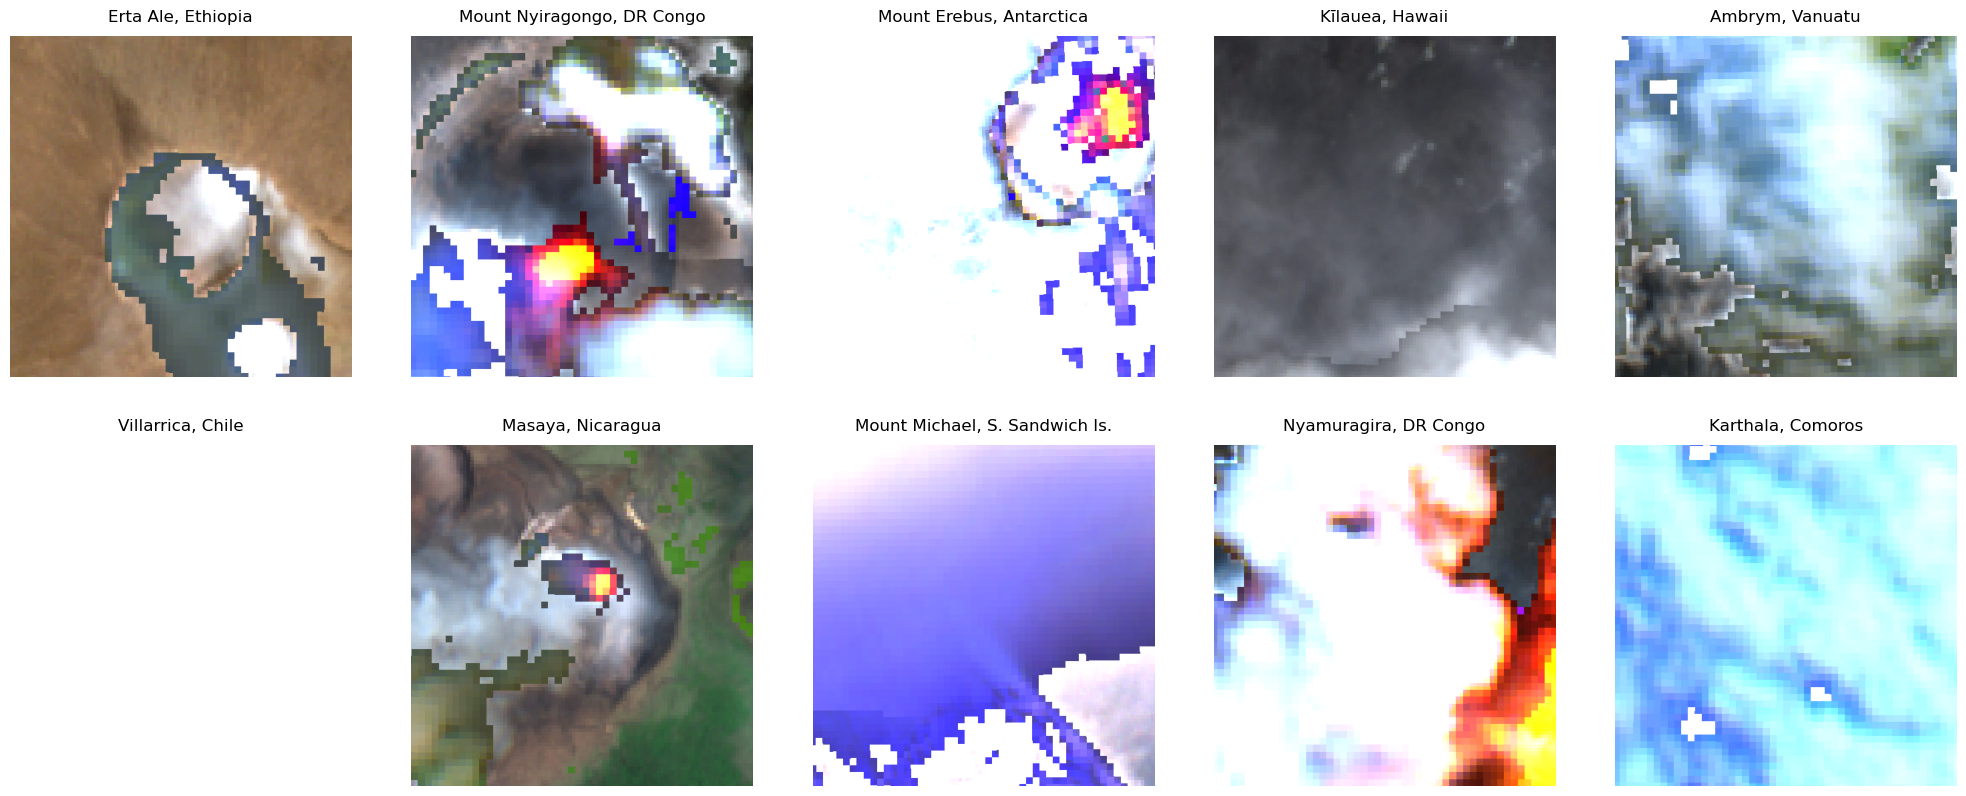

In [4]:
# %% [code]
# 1. Advanced Thermal Anomaly Evalscript
evalscript_thermal = """
//VERSION=3
function setup() {
  return {
    input: ["B02","B03","B04","B08","B8A","B11","B12","SCL","dataMask"],
    output: [
      { id: "default", bands: 3, sampleType: "UINT8" },
      { id: "index",   bands: 1, sampleType: "FLOAT32" },
      { id: "eobrowserStats", bands: 2, sampleType: "FLOAT32" },
      { id: "heatindices", bands: 2, sampleType: "FLOAT32" }, 
      { id: "dataMask", bands: 1, sampleType: "UINT8" } 
    ]
  };
}

// Thresholds
const SWIR_HOT_THRESHOLD = 0.20;
const SHI_THRESHOLD = 0.10;

// Stretch ranges
const TRUE_MIN = 0.0, TRUE_MAX = 0.30;
const SWIR_MIN = 0.05, SWIR_MAX = 0.60;

// Helpers
function stretch(v, a, b) {
  let x = (v - a) / (b - a);
  x = Math.max(0, Math.min(1, x));
  return Math.round(255 * x);
}

function getNIR(s) {
  return (s.B8A !== undefined && !isNaN(s.B8A)) ? s.B8A :
         (s.B08 !== undefined && !isNaN(s.B08)) ? s.B08 : 0.0;
}

// Strict cloud mask
function isClear(s) {
  if (s.SCL === undefined) return true;
  let c = s.SCL;
  if (c === 3) return false;          // cloud shadow
  if (c >= 8 && c <= 10) return false; // clouds
  return true;
}

// Purple heatmap for SHI
function purpleRamp(x) {
  x = Math.max(0, Math.min(1, x));
  return [
    Math.round(255 * x),
    Math.round(255 * 0.15 * x),
    255
  ];
}

function evaluatePixel(s) {
  // Return NaNs for empty border pixels so stats aren't skewed
  if (!s.dataMask) {
    return { 
      default: [0,0,0], 
      index: [NaN], 
      eobrowserStats: [NaN, NaN],
      heatindices: [NaN, NaN],
      dataMask: [0]
    };
  }

  let clear = isClear(s);
  let cloudFlag = clear ? 0 : 1;

  // True color
  let tc = [
    stretch(s.B04, TRUE_MIN, TRUE_MAX),
    stretch(s.B03, TRUE_MIN, TRUE_MAX),
    stretch(s.B02, TRUE_MIN, TRUE_MAX)
  ];

  // SWIR composite
  let swirRGB = [
    stretch(s.B12, SWIR_MIN, SWIR_MAX),
    stretch(s.B11, SWIR_MIN, SWIR_MAX),
    stretch(s.B04, SWIR_MIN, SWIR_MAX)
  ];

  // SHI calculation
  let nir = getNIR(s);
  let shi = (s.B12 + nir > 0) ? (s.B12 - nir) / (s.B12 + nir) : 0;

  // Classification
  let swirHot = s.B12 > SWIR_HOT_THRESHOLD;
  let shiHot = clear && (shi > SHI_THRESHOLD);

  // Prepare the custom Jupyter output [Band 0: SHI, Band 1: Raw B12]
  let heatindicesOutput = [shi, s.B12];

  // Output logic
  if (swirHot) {
    return {
      default: swirRGB,
      index:   [shi],
      eobrowserStats: [shi, cloudFlag],
      heatindices: heatindicesOutput,
      dataMask: [s.dataMask]
    };
  }

  if (shiHot) {
    return {
      default: purpleRamp(shi),
      index:   [shi],
      eobrowserStats: [shi, cloudFlag],
      heatindices: heatindicesOutput,
      dataMask: [s.dataMask]
    };
  }

  return {
    default: tc,
    index:   [shi],
    eobrowserStats: [shi, cloudFlag],
    heatindices: heatindicesOutput,
    dataMask: [s.dataMask]
  };
}
"""

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

print("Fetching latest thermal imagery from CDSE... This may take a moment.")

for i, volcano in enumerate(volcanoes):
    name = volcano["name"]
    lons = [c[0] for c in volcano["coords"]]
    lats = [c[1] for c in volcano["coords"]]

    bbox = BBox(bbox=[min(lons), min(lats), max(lons), max(lats)], crs=CRS.WGS84)

    request = SentinelHubRequest(
        evalscript=evalscript_thermal,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=cdse_s2_l2a,
                time_interval=(start_date, end_date),
                maxcc=0.80,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
        bbox=bbox,
        size=(512, 512),
        config=config,
    )

    try:
        response = request.get_data()
        if response and len(response) > 0:
            axes[i].imshow(response[0])
            axes[i].set_title(name, fontsize=12, pad=10)
        else:
            axes[i].set_title(f"{name}\n(No valid data)", fontsize=12, pad=10)
            axes[i].text(0.5, 0.5, "No Image Available", ha="center", va="center")
    except Exception as e:
        axes[i].set_title(f"{name}\n(Error)", fontsize=12, pad=10)
        print(f"Error fetching {name}: {e}")

    axes[i].axis("off")

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

Querying Statistical API for 14-day intervals over the last year...
This evaluates every single pixel, so it may take a minute or two.

✅ Successfully processed stats for Erta Ale, Ethiopia
✅ Successfully processed stats for Mount Nyiragongo, DR Congo
✅ Successfully processed stats for Mount Erebus, Antarctica
✅ Successfully processed stats for Kīlauea, Hawaii
✅ Successfully processed stats for Ambrym, Vanuatu
✅ Successfully processed stats for Villarrica, Chile
✅ Successfully processed stats for Masaya, Nicaragua
✅ Successfully processed stats for Mount Michael, S. Sandwich Is.
✅ Successfully processed stats for Nyamuragira, DR Congo
✅ Successfully processed stats for Karthala, Comoros

🌋 MAXIMUM SHI (Normalized Hotspot Index) PER 14-DAY INTERVAL


,2025-08-13,2025-08-27,2025-09-10,2025-09-24,2025-10-08,2025-10-22,2025-11-05,2025-11-19,2025-12-03,2025-12-17,...,2026-03-25,2026-04-08,2026-04-22,2026-05-06,2026-05-20,2026-06-03,2026-06-17,2026-07-01,2026-07-15,2026-07-29
"Erta Ale, Ethiopia",-0.001,0.012,-0.168,-0.095,-0.061,-0.046,-0.244,-0.113,-0.134,-0.171,...,-0.094,-0.099,-0.172,-0.100,-0.107,-0.091,-0.066,-0.072,-0.314,-0.131
"Mount Nyiragongo, DR Congo",-0.143,-0.329,-0.223,-0.257,-0.245,-0.279,-0.446,-0.502,-0.468,-0.179,...,-0.213,-0.229,-0.225,-0.216,-0.249,-0.244,-0.343,-0.257,-0.304,-0.069
"Kīlauea, Hawaii",0.764,0.627,0.420,-0.005,-0.317,-0.032,-0.271,-0.146,0.329,0.188,...,-0.256,0.148,-0.136,-0.654,-0.331,0.724,-0.213,0.044,-0.096,-0.012
"Ambrym, Vanuatu",-0.318,-0.494,-0.548,-0.358,-0.641,0.006,-0.382,0.076,-0.128,-0.628,...,-0.015,-0.752,-0.167,-0.855,-0.088,-0.228,-0.144,-0.152,-0.392,-0.132
"Villarrica, Chile",-0.997,-0.594,-0.542,-0.437,-0.904,-0.450,-0.219,-0.529,-0.491,-1.000,...,-0.914,-0.869,-0.464,-0.963,-0.190,-0.918,-0.409,-0.529,-0.844,-0.381
"Masaya, Nicaragua",-0.265,-0.155,-0.265,-0.228,-0.192,0.082,0.202,0.366,0.362,0.285,...,0.049,-0.043,-0.078,-0.149,-0.010,-0.339,-0.226,-0.260,0.019,0.120
"Mount Michael, S. Sandwich Is.",-0.697,-0.452,-0.501,-0.211,-0.376,-0.611,0.007,-0.446,-0.464,-0.350,...,-1.000,-0.193,-0.263,-0.067,-0.496,NaN,NaN,NaN,-0.402,-0.253
"Nyamuragira, DR Congo",0.024,-0.144,-0.425,-0.364,-0.021,-0.266,0.016,-0.360,-0.334,0.326,...,-0.407,-0.466,-0.394,-0.195,-0.275,-0.191,-0.135,-0.404,-0.338,-0.214
"Karthala, Comoros",-0.105,-0.053,-0.053,-0.052,-0.044,-0.208,-0.403,-0.020,-0.199,-0.155,...,-0.416,-0.064,-0.097,-0.135,-0.238,-0.087,-0.068,-0.089,-0.297,-0.328
"Mount Erebus, Antarctica",NaN,NaN,-0.284,-1.000,-0.796,-0.820,-0.831,-0.777,-0.758,-0.884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



🔥 MAXIMUM SWIR B12 RADIANCE PER 14-DAY INTERVAL


,2025-08-13,2025-08-27,2025-09-10,2025-09-24,2025-10-08,2025-10-22,2025-11-05,2025-11-19,2025-12-03,2025-12-17,...,2026-03-25,2026-04-08,2026-04-22,2026-05-06,2026-05-20,2026-06-03,2026-06-17,2026-07-01,2026-07-15,2026-07-29
"Erta Ale, Ethiopia",0.168,0.213,0.313,0.189,0.238,0.209,0.541,0.194,0.259,0.197,...,0.172,0.168,0.157,0.159,0.174,0.192,0.189,0.190,0.172,0.184
"Mount Nyiragongo, DR Congo",0.565,0.552,0.440,0.475,0.672,0.408,0.403,0.463,0.329,0.231,...,0.503,0.438,0.557,0.414,0.501,0.351,0.299,0.347,0.523,0.165
"Kīlauea, Hawaii",0.133,0.198,0.065,0.276,0.525,0.160,0.258,0.750,0.041,0.058,...,0.108,0.080,0.255,0.131,0.285,0.131,0.198,0.043,0.155,0.066
"Ambrym, Vanuatu",0.450,0.310,0.269,0.184,0.133,0.133,0.334,0.091,0.047,0.234,...,0.073,0.073,0.087,0.025,0.356,0.238,0.319,0.239,0.244,0.232
"Villarrica, Chile",0.001,0.236,0.360,0.465,0.039,0.177,0.500,0.311,0.358,0.000,...,0.016,0.053,0.268,0.013,0.300,0.037,0.427,0.249,0.047,0.392
"Masaya, Nicaragua",0.521,0.239,0.464,0.320,0.488,0.070,0.126,0.097,0.039,0.083,...,0.189,0.180,0.248,0.140,0.323,0.350,0.309,0.314,0.159,0.149
"Mount Michael, S. Sandwich Is.",0.129,0.275,0.248,0.385,0.501,0.190,0.537,0.184,0.144,0.384,...,0.000,0.128,0.544,0.243,0.200,NaN,NaN,NaN,0.375,0.391
"Nyamuragira, DR Congo",0.476,0.506,0.527,0.255,0.701,0.580,0.414,0.531,0.377,0.268,...,0.428,0.354,0.095,0.592,0.415,0.419,0.492,0.534,0.577,0.251
"Karthala, Comoros",0.108,0.408,0.127,0.116,0.138,0.401,0.456,0.231,0.134,0.304,...,0.226,0.454,0.168,0.090,0.335,0.105,0.159,0.105,0.254,0.391
"Mount Erebus, Antarctica",NaN,NaN,0.540,0.000,0.089,0.081,0.076,0.100,0.118,0.049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Generating 1-Year Activity Timelines...


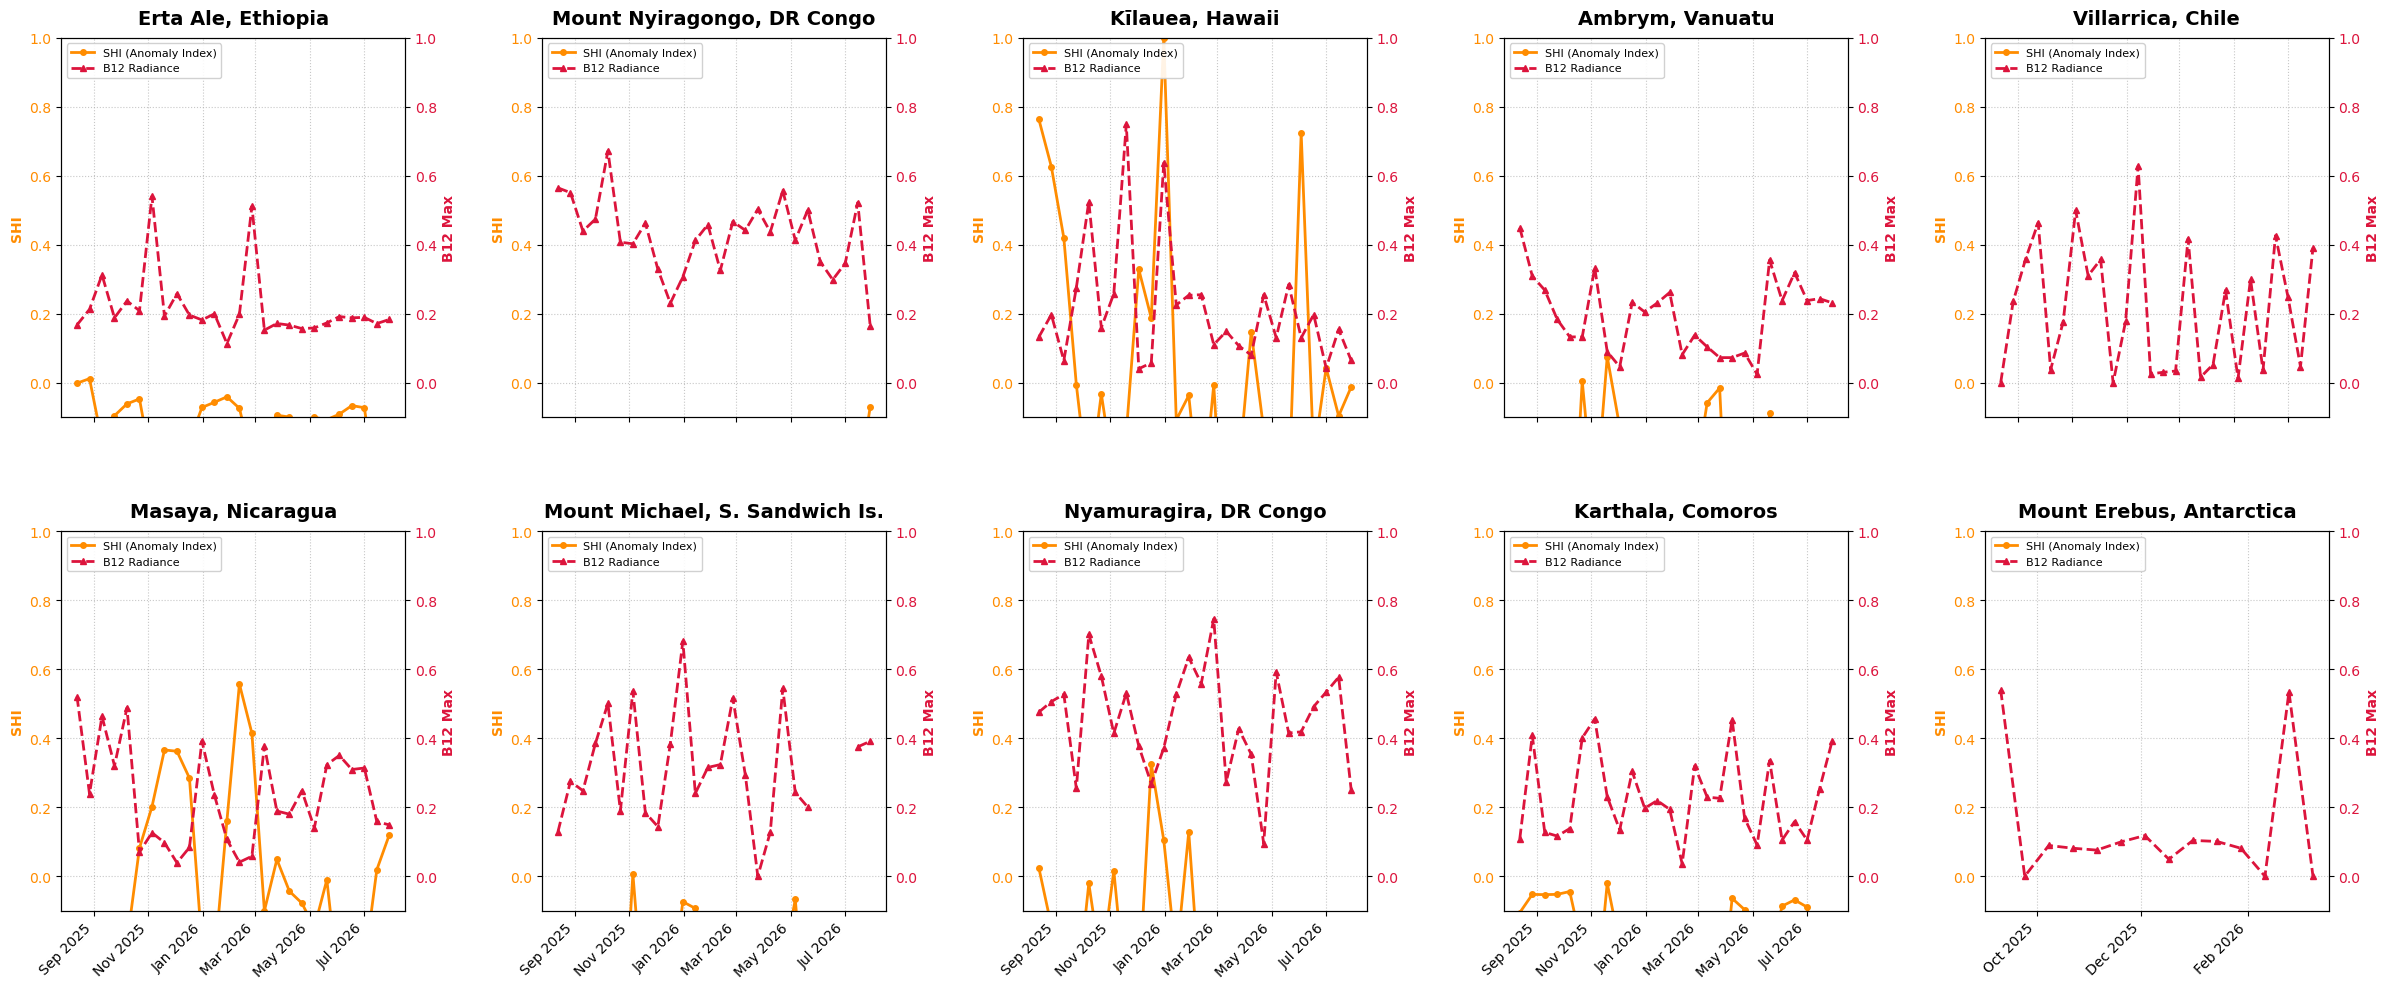

In [5]:
# %% [code]
import pandas as pd
from sentinelhub import SentinelHubStatistical
from IPython.display import display

# 1. Specialized Evalscript for the Statistical API
evalscript_stats = """
//VERSION=3
function setup() {
  return {
    input: ["B08", "B8A", "B11", "B12", "SCL", "dataMask"],
    output: [
      { id: "heatindices", bands: 2, sampleType: "FLOAT32" },
      { id: "dataMask", bands: 1, sampleType: "UINT8" } // Mandatory for stats calculation
    ]
  };
}

function getNIR(s) {
  return (s.B8A !== undefined && !isNaN(s.B8A)) ? s.B8A :
         (s.B08 !== undefined && !isNaN(s.B08)) ? s.B08 : 0.0;
}

function evaluatePixel(s) {
  // If no data, mask it out so it doesn't ruin the statistics
  if (!s.dataMask) {
    return { heatindices: [NaN, NaN], dataMask: [0] };
  }
  
  let nir = getNIR(s);
  let shi = (s.B12 + nir > 0) ? (s.B12 - nir) / (s.B12 + nir) : 0;
  
  return {
    heatindices: [shi, s.B12],
    dataMask: [1]
  };
}
"""

shi_records = {}
b12_records = {}

print("Querying Statistical API for 14-day intervals over the last year...")
print("This evaluates every single pixel, so it may take a minute or two.\n")

for volcano in volcanoes:
    name = volcano["name"]
    lons = [c[0] for c in volcano["coords"]]
    lats = [c[1] for c in volcano["coords"]]

    bbox = BBox(bbox=[min(lons), min(lats), max(lons), max(lats)], crs=CRS.WGS84)

    aggregation = SentinelHubStatistical.aggregation(
        evalscript=evalscript_stats,
        time_interval=(start_date, end_date),
        aggregation_interval="P14D",
        resolution=(20, 20),
    )

    request = SentinelHubStatistical(
        aggregation=aggregation,
        input_data=[
            SentinelHubStatistical.input_data(cdse_s2_l2a)
        ],  # Note: We dropped maxcc here
        bbox=bbox,
        config=config,
    )

    try:
        response = request.get_data()[0]

        shi_row = {}
        b12_row = {}

        for interval_data in response["data"]:
            date_str = interval_data["interval"]["from"][:10]
            outputs = (
                interval_data.get("outputs", {}).get("heatindices", {}).get("bands", {})
            )

            shi_max = outputs.get("B0", {}).get("stats", {}).get("max", float("nan"))
            b12_max = outputs.get("B1", {}).get("stats", {}).get("max", float("nan"))

            shi_row[date_str] = shi_max
            b12_row[date_str] = b12_max

        shi_records[name] = shi_row
        b12_records[name] = b12_row
        print(f"✅ Successfully processed stats for {name}")

    except Exception as e:
        print(f"❌ Error querying {name}: {e}")

df_shi = pd.DataFrame.from_dict(shi_records, orient="index")
df_b12 = pd.DataFrame.from_dict(b12_records, orient="index")

df_shi = df_shi.reindex(sorted(df_shi.columns), axis=1)
df_b12 = df_b12.reindex(sorted(df_b12.columns), axis=1)

print("\n" + "=" * 80)
print("🌋 MAXIMUM SHI (Normalized Hotspot Index) PER 14-DAY INTERVAL")
print("=" * 80)
display(df_shi.round(3))

print("\n" + "=" * 80)
print("🔥 MAXIMUM SWIR B12 RADIANCE PER 14-DAY INTERVAL")
print("=" * 80)
display(df_b12.round(3))

# %% [code]
import matplotlib.dates as mdates
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

dates_pd = pd.to_datetime(df_shi.columns)

print("Generating 1-Year Activity Timelines...")

for i, volcano_name in enumerate(df_shi.index):
    ax1 = axes[i]

    shi_data = df_shi.loc[volcano_name].fillna(np.nan).values
    b12_data = df_b12.loc[volcano_name].fillna(np.nan).values

    # SHI (Orange) on Primary Left Axis
    color1 = "darkorange"
    line1 = ax1.plot(
        dates_pd,
        shi_data,
        color=color1,
        marker="o",
        markersize=4,
        linestyle="-",
        linewidth=2,
        label="SHI (Anomaly Index)",
    )

    ax1.set_ylabel("SHI", color=color1, fontsize=10, fontweight="bold")
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.set_ylim(-0.1, 1.0)

    # B12 Radiance (Red) on Secondary Right Axis
    ax2 = ax1.twinx()
    color2 = "crimson"
    line2 = ax2.plot(
        dates_pd,
        b12_data,
        color=color2,
        marker="^",
        markersize=4,
        linestyle="--",
        linewidth=2,
        label="B12 Radiance",
    )

    ax2.set_ylabel("B12 Max", color=color2, fontsize=10, fontweight="bold")
    ax2.tick_params(axis="y", labelcolor=color2)

    max_b12 = np.nanmax(b12_data) if not np.isnan(b12_data).all() else 1.0
    ax2.set_ylim(-0.1, max(1.0, max_b12 * 1.1))

    ax1.set_title(volcano_name, fontsize=14, pad=10, fontweight="bold")
    ax1.grid(True, linestyle=":", alpha=0.7)

    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left", fontsize=8, framealpha=0.9)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace=0.3)
plt.show()

In [6]:
# %% [code]
import ipywidgets as widgets

# 1. Define our Activity Thresholds
SHI_THRESHOLD = 0.10
B12_THRESHOLD = 0.20

dates_list = list(df_shi.columns)


def draw_dashboard(date_str):
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    axes = axes.flatten()

    fig.suptitle(
        f"Lava Lake Activity Status\n14-Day Interval Starting: {date_str}",
        fontsize=22,
        fontweight="bold",
        y=1.05,
    )

    for i, volcano_name in enumerate(df_shi.index):
        ax = axes[i]

        shi_val = df_shi.loc[volcano_name, date_str]
        b12_val = df_b12.loc[volcano_name, date_str]

        status = "NO DATA"
        is_active = False

        if pd.notna(shi_val) and pd.notna(b12_val):
            if shi_val > SHI_THRESHOLD or b12_val > B12_THRESHOLD:
                status = "ACTIVE"
                is_active = True
            else:
                status = "INACTIVE"

        if status == "ACTIVE":
            bg_color = "firebrick"
            text_color = "white"
        elif status == "INACTIVE":
            bg_color = "lightgrey"
            text_color = "dimgrey"
        else:
            bg_color = "#2b2b2b"
            text_color = "#aaaaaa"

        ax.set_facecolor(bg_color)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.text(
            0.5,
            0.7,
            volcano_name.replace(", ", "\n"),
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=text_color,
        )

        ax.text(
            0.5,
            0.4,
            status,
            ha="center",
            va="center",
            fontsize=24,
            fontweight="heavy",
            color=text_color,
        )

        if status != "NO DATA":
            metrics = f"Max SHI: {shi_val:.2f}  |  Max B12: {b12_val:.2f}"
            ax.text(
                0.5,
                0.15,
                metrics,
                ha="center",
                va="center",
                fontsize=11,
                color=text_color,
            )

    plt.tight_layout()
    plt.show()


date_slider = widgets.SelectionSlider(
    options=dates_list,
    value=dates_list[0],
    description="Select Date:",
    disabled=False,
    continuous_update=False,
    orientation="horizontal",
    readout=True,
    layout={"width": "800px"},
)

print("Use the slider below to step through time:")
widgets.interact(draw_dashboard, date_str=date_slider);

Use the slider below to step through time:


interactive(children=(SelectionSlider(continuous_update=False, description='Select Date:', layout=Layout(width…

In [7]:
# %% [code]
# 1. Dynamically calculate the last 10 days
end_date_10d = datetime.now().strftime("%Y-%m-%d")
start_date_10d = (datetime.now() - timedelta(days=10)).strftime("%Y-%m-%d")

print(f"Scanning for active lava lakes between {start_date_10d} and {end_date_10d}...")

active_volcanoes = []

# 2. Query the Statistical API for each volcano
for volcano in volcanoes:
    name = volcano["name"]
    lons = [c[0] for c in volcano["coords"]]
    lats = [c[1] for c in volcano["coords"]]

    bbox = BBox(bbox=[min(lons), min(lats), max(lons), max(lats)], crs=CRS.WGS84)

    aggregation = SentinelHubStatistical.aggregation(
        evalscript=evalscript_stats,
        time_interval=(start_date_10d, end_date_10d),
        aggregation_interval="P10D",
        resolution=(20, 20),
    )

    request = SentinelHubStatistical(
        aggregation=aggregation,
        input_data=[SentinelHubStatistical.input_data(cdse_s2_l2a)],
        bbox=bbox,
        config=config,
    )

    try:
        response = request.get_data()[0]

        shi_max = float("nan")
        b12_max = float("nan")

        if response["data"] and len(response["data"]) > 0:
            outputs = (
                response["data"][0]
                .get("outputs", {})
                .get("heatindices", {})
                .get("bands", {})
            )
            shi_max = outputs.get("B0", {}).get("stats", {}).get("max", float("nan"))
            b12_max = outputs.get("B1", {}).get("stats", {}).get("max", float("nan"))

        # 3. Apply the activity logic
        if shi_max > SHI_THRESHOLD or b12_max > B12_THRESHOLD:
            active_volcanoes.append(name)

    except Exception as e:
        print(f"Warning: Could not process {name}. Error: {e}")

# 4. Output the final string
print("\n" + "=" * 50)
print("🌋 CURRENTLY ACTIVE LAVA LAKES")
print("=" * 50)

if len(active_volcanoes) > 0:
    active_string = ", ".join(active_volcanoes)
    print(f"Active List: [{active_string}]")
else:
    print(
        "No active lava lakes detected in the last 10 days (or all obscured by clouds)."
    )

Scanning for active lava lakes between 2026-08-03 and 2026-08-13...

🌋 CURRENTLY ACTIVE LAVA LAKES
Active List: [Ambrym, Vanuatu, Masaya, Nicaragua, Mount Michael, S. Sandwich Is., Nyamuragira, DR Congo, Karthala, Comoros]


### Reflection: Can AI prepare a good CDSE Jupyter notebook?

**What worked well:**
* **Execution:** All cells execute successfully.
* **Accuracy:** The notebook works according to the initial specifications.
* **Documentation:** The code is commented to a reasonable extent, explaining the steps.

**The Cons (Areas for improvement):**
* **Logical Misinterpretations:** Subtle mistakes can remain in the code. For example, relying on the length of the response array in Cell 2 to check for valid data isn't perfectly robust; the technically correct way to handle that is by evaluating the `dataMask`.
* **Stale Code:** As a notebook is updated through prompt iterations, defined but unused variables can be left behind (e.g., the `heatindices` output in Cell 3, or the `is_active` flag in Cell 5).
* **Basic UX:** The user experience defaults to basic unless heavily prompted. For instance, a human would likely format the final active volcano list dynamically, rather than dumping it into one long string.

**The Verdict:**
>> **Yes, but always check thoroughly and make sure you know what you are doing.** AI is a powerful drafting tool, but human expertise is essential to review, optimize, and polish the logic.